# BART Ridership Recovery & Expansion Projections: A Post-COVID Analysis

## Overview
This project investigates which BART (Bay Area Rapid Transit) stations recovered 
from pandemic-era ridership loss and what neighborhood characteristics predict 
recovery. Using 96 months of ridership data across 48 stations, I built a 
data pipeline, tested demographic hypotheses, and applied k-means clustering 
to project ridership performance at 13 proposed BART expansion stations.

## Research Question
- Did BART recover to pre-pandemic ridership levels, and which station and 
neighborhood characteristics predict which stations bounced back?
- Given the recovery of the stations, how well will future comparable stations perform?

## Data Sources
- **BART Monthly Ridership Data** (2018–2025): Origin-destination matrices 
  downloaded from bart.gov. 96 Excel files totaling ~240,000 rows.
- **BART 2024 Station Profile Study**: Rider income demographics by station.
- **U.S. Census ACS 5-Year Estimates (2023)**: 
  - Table B01003: Population by ZIP Code (density calculation)
  - Table B19013: Median Household Income by ZIP Code

## Methodology

### Phase 1: Data Pipeline
Built a reusable `load_and_clean_month()` function to handle BART's 
inconsistent Excel formats across 96 files. Produced a unified DataFrame 
of 240,000+ rows with origin, destination, trips, and month columns.

### Phase 2: Exploration & Validation
Validated data integrity with sanity checks against raw files. Identified 
and removed phantom trips (same origin and destination) and malformed rows.

### Phase 3: Recovery Analysis
Defined a pre-COVID baseline as the average of January 2018 – February 2020. 
Calculated a recovery index (current trips ÷ baseline trips) for each station 
each month. Built a system-wide recovery curve and station-level rankings.

**Key finding:** Suburban stations (e.g., Antioch) significantly outperformed 
downtown SF financial district stations (e.g., Montgomery) in recovery.

### Phase 4: Demographic Layer
Joined rider income data from BART's Station Profile Study and population 
density from Census ACS to test two hypotheses:

- **Hypothesis 1:** High-income stations would recover worse due to remote work
- **Hypothesis 2:** High-density urban stations would retain more riders

**Finding:** Neither income nor population density meaningfully predicted 
recovery — both hypotheses were rejected. This suggests recovery is driven 
by station-specific factors beyond neighborhood demographics alone.

### Phase 5: Expansion Station Analysis

Applied k-means clustering (k=3, validated by elbow method) to group existing 
stations by population density and median household income. 
Three clusters emerged:

| Cluster | Profile | Avg Recovery Index |
|---------|---------|-------------------|
| 0 | Suburban Middle | 0.360 |
| 1 | Dense Urban | 0.303 |
| 2 | Wealthy Low Density | 0.315 |

**Why k-means clustering?**

k-means clustering was selected because it's unsupervised, interpretable, and works well for small datasets. 
I only had 48 stations so simpler was better. 

**Why three clusters?**

Using the Elbow method, I plotted WCSS against k and found the curve flattened after 3.

Proposed stations across three corridors were scaled and assigned to their 
nearest demographic cluster to project performance:

- **VTA Silicon Valley (4 stations):** 0.303–0.360 projected recovery
- **East Bay — Livermore & Irvington (2 stations):** 0.315 projected recovery
- **Contra Costa/eBART (7 stations):** 0.360 projected recovery

**Notable finding:** As more stations open along the SR-4 corridor, Antioch's 
ridership dominance may diminish as trips distribute across new stations — 
similar to how Castro Valley transitioned from a terminus to a mid-line station.

## Key Visualizations
- System-wide recovery curve (2018–2025)
- Station-level recovery rankings
- Recovery index vs. high-income rider share (null result)
- Recovery index vs. population density (null result)
- K-means cluster scatter plot: existing vs. proposed stations
- Projected recovery bar chart by corridor

## Tools & Technologies
- **Python** — pandas, matplotlib, scikit-learn, requests
- **Jupyter Lab** — analysis and narrative notebook
- **Census API** — programmatic data retrieval
- **SQLite** — in-memory SQL queries for station aggregations
- **Git/GitHub** — version control

## Limitations
- Demographics from 2024 applied to 2018–2023 recovery period introduces 
  a temporal mismatch. Gentrification in Oakland and Mission District stations 
  may have shifted demographic profiles since 2018.
- Proposed station projections assume demographic similarity predicts 
  performance. Given that demographics showed weak predictive power for 
  existing stations, these should be interpreted as benchmarks, not forecasts.
- K-means clustering on 48 stations is a small sample. Cluster assignments 
  should be interpreted with caution.

## Key Findings
- BART system-wide ridership remained at ~35% of pre-COVID baseline as of December 2023
- Suburban terminus stations (AN, PC, RM) outperformed dense urban stations
- Neither income nor population density predicted recovery — both hypotheses rejected
- Proposed Contra Costa stations project strongest recovery (0.360) based on demographic similarity to existing suburban stations

## Repository Structure


 ## Bart Post-COVID Recovery Analysis

 ## Question Which BART stations recovered to pre-pandemic ridership levels, if at all? 

 Data: BART monthly origin-destination matrices, 2018–2025, 
 downloaded from bart.gov. Each file contains four tabs (Total Trips, 
 Average Weekday, Average Saturday, Average Sunday) and is structured 
 as a wide matrix with origin stations across columns and destination 
 stations down rows.


 Notebook 1 of N: Initial data exploration — understanding what 
 BART actually publishes before doing any analysis.

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import sqlite3
import shutil



In [2]:

data_path = '../Data/raw'
print(os.listdir(data_path))

#rename
for folder_name in os.listdir(data_path):
    if folder_name == '.DS_Store':
        continue
    
    full_path = os.path.join(data_path, folder_name)
    if not os.path.isdir(full_path):
        continue
    
    new_name = folder_name.lower().replace(" ", "_")
    
    if new_name != folder_name:
        old_path = os.path.join(data_path, folder_name)
        new_path = os.path.join(data_path, new_name)
        os.rename(old_path, new_path)
        print(f"renamed: '{folder_name}'  →  '{new_name}'")


['.DS_Store', 'ridership_2018', 'ridership_2020', 'ridership_2021', 'ridership_2019', 'station_profile_2024.xlsx', 'station_crosswalk.csv', 'population_zipcode_data_2023', 'Gazetteer Files 2023.zip', 'ridership_2023', 'ridership_2024', 'ridership_2025', 'ridership_2022', 'acsdt5y2023.b19013_2026-05-10t184226', '2023_Gaz_zcta_national.txt', 'bart_abbs.xls']


In [3]:
#rename
for folder_name in os.listdir(data_path):
    if folder_name == ".DS_Store":
        continue
    
    full_path = os.path.join(data_path, folder_name)
    if not os.path.isdir(full_path):
        continue
    
    new_name = folder_name.lower().replace(" ", "_")
    
    if new_name != folder_name:
        old_path = os.path.join(data_path, folder_name)
        new_path = os.path.join(data_path, new_name)
        os.rename(old_path, new_path)
        print(f"renamed: '{folder_name}'  →  '{new_name}'")

In [4]:
year_2024_p = "../Data/raw/ridership_2024"

for folder_name in sorted(os.listdir(year_2024_p)):
    if folder_name != ".DS_Store":
        print(folder_name)


Ridership_202401.xlsx
Ridership_202402.xlsx
Ridership_202403.xlsx
Ridership_202404.xlsx
Ridership_202405.xlsx
Ridership_202406.xlsx
Ridership_202407.xlsx
Ridership_202408.xlsx
Ridership_202409.xlsx
Ridership_202410.xlsx
Ridership_202411.xlsx
Ridership_202412.xlsx


In [5]:
import pandas as pd

file_path = os.path.join(year_2024_p, "Ridership_202401.xlsx")

xl = pd.ExcelFile(file_path)

print(xl.sheet_names)

['Total Trips', 'Average Weekday', 'Average Saturday', 'Average Sunday']


 Step 3: Open the Average Weekday tab

 For recovery analysis, I'll focus on Average Weekday ridership 
 since that's the metric most affected by post-COVID work-from-home 
 patterns. Weekend ridership tells a different story.

 Each tab is structured as a wide origin-destination matrix with 
 origin stations across the columns and destination stations down 
 the rows. Each cell is the average number of trips between those 
 two stations on a typical weekday that month.

In [6]:
weekday_jan_2024 = pd.read_excel(file_path, sheet_name = "Average Weekday")
weekday_jan_2024.head()

,Avg Weekday Trip OD,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 / 01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,...,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday
3,Exit Station Two-Letter Code,RM,EN,EP,NB,BK,AS,MA,19,12,...,SO,MB,WD,OA,WS,PC,AN,ML,BE,NaN
4,RM,12.428571,69.666667,58.428571,33.571429,222.714286,47.095238,75.761905,62.190476,76.142857,...,35.857143,11.47619,4.190476,7.809524,13.333333,3.952381,10.47619,5.238095,6,2054.857143


In [7]:
weekday_jan_2024 = pd.read_excel(file_path, sheet_name = "Average Weekday")
weekday_jan_2024.head()

,Avg Weekday Trip OD,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50,Unnamed: 51
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 / 01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,...,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday,Avg Weekday
3,Exit Station Two-Letter Code,RM,EN,EP,NB,BK,AS,MA,19,12,...,SO,MB,WD,OA,WS,PC,AN,ML,BE,NaN
4,RM,12.428571,69.666667,58.428571,33.571429,222.714286,47.095238,75.761905,62.190476,76.142857,...,35.857143,11.47619,4.190476,7.809524,13.333333,3.952381,10.47619,5.238095,6,2054.857143


In [8]:
weekday_jan_2024 = pd.read_excel(file_path,skiprows=4)
print(weekday_jan_2024)

   Exit Station Two-Letter Code     RM     EN     EP     NB      BK     AS  \
0                            RM    425   1800   1556    870    5754   1216   
1                            EN   1822    545   1712   1258    9138   1528   
2                            EP   1651   1528    219    884    7677   1167   
3                            NB    884   1056    878    266    2015    648   
4                            BK   6545   9449   7961   2310    1083   3814   
5                            AS   1189   1484   1260    815    3710    297   
6                            MA   2306   2615   1423    987    3854   1073   
7                            19   1700   3598   2307   2055    5049   2138   
8                            12   1993   4282   2526   1897    5024   2019   
9                            LM    521    920    629    498    2225    636   
10                           FV   1358   1586    679    753    3026   1362   
11                           CL   1054    872    247    338    1

In [9]:
!pip install xlrd

In [10]:
stations_p = "../Data/raw/bart_abbs.xls"
stations = pd.read_excel(stations_p, usecols=['Two-Letter Station Code', 'Station Name'])
stations.head()

stations

,Two-Letter Station Code,Station Name
0,RM,Richmond
1,EN,El Cerrito Del Norte
2,EP,El Cerrito Plaza
3,NB,North Berkeley
4,BK,Berkeley
5,AS,Ashby
6,MA,MacArthur
7,19,19th Street Oakland
8,12,12th Street / Oakland City Center
9,LM,Lake Merritt


In [11]:
weekday_jan_2024_long = pd.melt(weekday_jan_2024, id_vars = "Exit Station Two-Letter Code", var_name = "origin", value_name = "trips" )

 Data Above is very long with several "phantom trips"
 Phantom trips can be identified with the same origin and same destination
 Exit Station Two Letter Code needs to be renamed to Origin after further inspection and 

In [12]:

weekday_jan_2024_long[
    (weekday_jan_2024_long["Exit Station Two-Letter Code"] == "EM") &
    (weekday_jan_2024_long["origin"] == "WC")
]

,Exit Station Two-Letter Code,origin,trips
1045,EM,WC,12852


In [13]:
weekday_jan_2024_long = weekday_jan_2024_long.rename(
    columns={"Exit Station Two-Letter Code": "destination"})
weekday_jan_2024_long.head()

,destination,origin,trips
0,RM,RM,425
1,EN,RM,1822
2,EP,RM,1651
3,NB,RM,884
4,BK,RM,6545


In [14]:
weekday_jan_2024_long = weekday_jan_2024_long[["origin", "destination", "trips"]]
weekday_jan_2024_long.head()


,origin,destination,trips
0,RM,RM,425
1,RM,EN,1822
2,RM,EP,1651
3,RM,NB,884
4,RM,BK,6545


###
#Cleaning up Filters like "Grand Total" and "Unamed"


In [15]:
weekday_jan_2024_long["destination"].unique()

array(['RM', 'EN', 'EP', 'NB', 'BK', 'AS', 'MA', '19', '12', 'LM', 'FV',
       'CL', 'SL', 'BF', 'HY', 'SH', 'UC', 'FM', 'CN', 'PH', 'WC', 'LF',
       'OR', 'RR', 'OW', 'EM', 'MT', 'PL', 'CC', '16', '24', 'GP', 'BP',
       'DC', 'CM', 'CV', 'ED', 'NC', 'WP', 'SS', 'SB', 'SO', 'MB', 'WD',
       'OA', 'WS', 'PC', 'AN', 'ML', 'BE', 'Grand Total'], dtype=object)

In [16]:
weekday_jan_2024_clean = weekday_jan_2024_long[
    (weekday_jan_2024_long['origin'] != weekday_jan_2024_long['destination']) &
    (weekday_jan_2024_long['destination'] != 'Grand Total') &
    (weekday_jan_2024_long['origin'] != 'Unnamed: 51')
].copy()

weekday_jan_2024_clean.shape

(2450, 3)


 Adding a month column so each row carries its own date. 
 Once we stack data from all 96 files into one DataFrame, this column will let us filter, 
 group, and compare across months — without it, 
 all the rows would look identical regardless of which month they came from.

In [17]:
weekday_jan_2024_clean["month"] = "2024-01"

In [18]:
### Next step: build a reusable function

# After exploring how one BART monthly file is structured, the next step 
# is to wrap the entire cleaning process into a single function. That way, 
# applying the same recipe to all 96 monthly files becomes a one-line call 
# inside a loop.

In [19]:
def find_header_row(file_path, sheet_name):
    raw = pd.read_excel(file_path, sheet_name=sheet_name, header=None)
    for i in range(len(raw)):
        cell = raw.iloc[i, 0]
        if isinstance(cell, str) and 'Exit Station' in cell:
            return i
    return None 
    

In [20]:
def load_and_clean_month(file_path):

    xl = pd.ExcelFile(file_path)
    filename = os.path.basename(file_path)
    
    weekday_sheet = None
    for sheet in xl.sheet_names:
        if "Weekday" in sheet:
            weekday_sheet = sheet
            break

    if "OD" in weekday_sheet:
        skip = 1
    # These 2 files (out of 96) have one fewer header row than their siblings,
    # so the station-code row is at index 3 instead of 4. skiprows=3 fixes them.
    elif filename in ["Ridership_202410.xlsx" , "Ridership_202508.xlsx"]:
        skip = 3
    else:
        skip = 4
           
    ridership_df = pd.read_excel(file_path, sheet_name= weekday_sheet, skiprows = skip)
    ridership_df = pd.melt(ridership_df, id_vars=ridership_df.columns[0], var_name="origin", value_name="trips")
    ridership_df = ridership_df.rename(columns={ridership_df.columns[0]: "destination"})
    ridership_df = ridership_df[["origin", "destination", "trips"]]
    ridership_df = ridership_df[
            (ridership_df["origin"] != ridership_df["destination"]) &
        (ridership_df["destination"] != "Grand Total") &
        (ridership_df["origin"] != "Unnamed: 51")].copy()
    ridership_df["month"] = f"{filename[10:14]}-{filename[14:16]}"
    return ridership_df


In [21]:
test = load_and_clean_month("../Data/raw/ridership_2024/Ridership_202401.xlsx")
test.shape

(2450, 4)

#sanity check

In [22]:
test_march = load_and_clean_month("../Data/raw/ridership_2024/Ridership_202403.xlsx")
test_march.shape
test_march.head()

,origin,destination,trips,month
1,RM,EN,70.476190,2024-03
2,RM,EP,64.666667,2024-03
3,RM,NB,35.666667,2024-03
4,RM,BK,283.333333,2024-03
5,RM,AS,44.666667,2024-03


### Next Step: Creating a Loop to go through the files BART has Published

In [23]:
all_months = []

for year_folder in sorted(os.listdir(data_path)):
    year_path = os.path.join(data_path, year_folder)
    if not os.path.isdir(year_path):
        continue
    
    for filename in sorted(os.listdir(year_path)):
        if filename == ".DS_Store":
                continue
        if not filename.endswith('.xls') and not filename.endswith('.xlsx'):
                continue

        full_path = os.path.join(year_path, filename)
        print(full_path)
        cleaned = load_and_clean_month(full_path)
        all_months.append(cleaned)

all_data = pd.concat(all_months, ignore_index=True)
all_data.shape        

    

../Data/raw/ridership_2018/Ridership_201801.xlsx
../Data/raw/ridership_2018/Ridership_201802.xlsx
../Data/raw/ridership_2018/Ridership_201803.xlsx
../Data/raw/ridership_2018/Ridership_201804.xlsx
../Data/raw/ridership_2018/Ridership_201805.xlsx
../Data/raw/ridership_2018/Ridership_201806.xlsx
../Data/raw/ridership_2018/Ridership_201807.xlsx
../Data/raw/ridership_2018/Ridership_201808.xlsx
../Data/raw/ridership_2018/Ridership_201809.xlsx
../Data/raw/ridership_2018/Ridership_201810.xlsx
../Data/raw/ridership_2018/Ridership_201811.xlsx
../Data/raw/ridership_2018/Ridership_201812.xlsx
../Data/raw/ridership_2019/Ridership_201901.xlsx
../Data/raw/ridership_2019/Ridership_201902.xlsx
../Data/raw/ridership_2019/Ridership_201903.xlsx
../Data/raw/ridership_2019/Ridership_201904.xlsx
../Data/raw/ridership_2019/Ridership_201905.xlsx
../Data/raw/ridership_2019/Ridership_201906.xlsx
../Data/raw/ridership_2019/Ridership_201907.xlsx
../Data/raw/ridership_2019/Ridership_201908.xlsx
../Data/raw/ridershi

(240920, 4)

In [24]:
all_data.shape

(240920, 4)

In [25]:
all_data['month'].value_counts().sort_index()

month
2018-01    2163
2018-02    2163
2018-03    2163
2018-04    2163
2018-05    2551
           ... 
2025-08    2450
2025-09    2450
2025-10    2450
2025-11    2450
2025-12    2450
Name: count, Length: 96, dtype: int64

In [26]:
# Are months continuous, no gaps?
print(all_data['month'].nunique())   # how many distinct months — should be 96 (or however many you actually downloaded)

96


In [27]:
all_data[
    (all_data['origin'] == 'EM') &
    (all_data['destination'] == 'WC')
].sort_values('month').head(20)

,origin,destination,trips,month
1170,EM,WC,1429.238095,2018-01
3333,EM,WC,1388.842105,2018-02
5496,EM,WC,1376.318182,2018-03
7659,EM,WC,1377.095238,2018-04
9922,EM,WC,1391.227273,2018-05
12473,EM,WC,1452.476190,2018-06
15024,EM,WC,1434.238095,2018-07
17575,EM,WC,1425.956522,2018-08
20126,EM,WC,1431.473684,2018-09
22677,EM,WC,1405.727273,2018-10


In [28]:
all_data[(all_data["origin"] == "EM") & (all_data["destination"] == "WC") & (all_data["month"] == "2024-01")]
all_data[(all_data["origin"] == "WC") & (all_data["destination"] == "EM") & (all_data["month"] == "024-01")]

,origin,destination,trips,month


In [29]:
result = all_data.groupby('origin')['trips'].sum()
result

origin
12       9.936862e+05
16       1.000962e+06
19       9.512260e+05
24       9.818565e+05
12       1.272378e+05
16       1.361661e+05
19       1.147987e+05
24       1.347773e+05
AN       2.801771e+05
AS       4.340816e+05
BE       9.687304e+04
BF       5.056756e+05
BK       9.753041e+05
BP       9.664058e+05
CC       2.096639e+06
CL       5.462683e+05
CM       3.620429e+05
CN       5.127417e+05
CV       2.453404e+05
DC       8.468601e+05
ED       6.657730e+05
EM       3.291522e+06
EN       7.206949e+05
EP       4.140408e+05
Exits    3.102611e+07
FM       4.757604e+05
FV       7.601927e+05
GP       6.654233e+05
HY       4.362726e+05
LF       2.954889e+05
LM       6.115422e+05
MA       7.686522e+05
MB       4.903381e+05
ML       8.251465e+04
MT       3.219370e+06
NB       3.604036e+05
NC       1.729425e+05
OA       1.302291e+05
OR       2.481653e+05
OW       7.132360e+05
PC       1.054536e+05
PH       5.971085e+05
PL       2.576963e+06
RM       4.448163e+05
RR       4.567848e+05
SB 

In [30]:
all_data['origin'].unique()

array(['RM', 'EN', 'EP', 'NB', 'BK', 'AS', 'MA', 19, 12, 'LM', 'FV', 'CL',
       'SL', 'BF', 'HY', 'SH', 'UC', 'FM', 'CN', 'PH', 'WC', 'LF', 'OR',
       'RR', 'OW', 'EM', 'MT', 'PL', 'CC', 16, 24, 'GP', 'BP', 'DC', 'CM',
       'CV', 'ED', 'NC', 'WP', 'SS', 'SB', 'SO', 'MB', 'WD', 'OA', 'WS',
       'Exits', 'ML', 'BE', 'PC', 'AN', '19', '12', '16', '24'],
      dtype=object)

In [31]:
all_data['origin'].value_counts()

origin
RM       4760
RR       4760
EM       4760
MT       4760
EN       4760
CC       4760
GP       4760
BP       4760
DC       4760
CM       4760
CV       4760
ED       4760
NC       4760
WP       4760
SS       4760
SB       4760
SO       4760
MB       4760
WD       4760
OA       4760
WS       4760
OW       4760
PL       4760
OR       4760
BF       4760
EP       4760
NB       4760
BK       4760
AS       4760
MA       4760
LF       4760
LM       4760
FV       4760
CL       4760
SL       4760
HY       4760
SH       4760
UC       4760
FM       4760
CN       4760
PH       4760
WC       4760
ML       4576
PC       4576
BE       4576
AN       4576
Exits    3656
12       3584
19       3584
24       3584
16       3584
19       1176
12       1176
16       1176
24       1176
Name: count, dtype: int64

In [32]:
test_2018 = pd.read_excel('../Data/raw/ridership_2018/Ridership_201801.xlsx', sheet_name='Weekday OD', skiprows=1)
test_2018.columns.tolist()

['Unnamed: 0',
 'RM',
 'EN',
 'EP',
 'NB',
 'BK',
 'AS',
 'MA',
 19,
 12,
 'LM',
 'FV',
 'CL',
 'SL',
 'BF',
 'HY',
 'SH',
 'UC',
 'FM',
 'CN',
 'PH',
 'WC',
 'LF',
 'OR',
 'RR',
 'OW',
 'EM',
 'MT',
 'PL',
 'CC',
 16,
 24,
 'GP',
 'BP',
 'DC',
 'CM',
 'CV',
 'ED',
 'NC',
 'WP',
 'SS',
 'SB',
 'SO',
 'MB',
 'WD',
 'OA',
 'WS',
 'Exits']

In [33]:
# Find rows where origin is a decimal-looking value
weird = all_data[all_data['origin'] == 23.818181818181813]
weird['month'].unique()


array([], dtype=object)

In [34]:
# Check the data type of each origin value
all_data['origin'].apply(type).value_counts()

origin
<class 'str'>    226584
<class 'int'>     14336
Name: count, dtype: int64

In [35]:
bad_rows = all_data[all_data['origin'].apply(type) == float]
bad_rows['month'].unique()

array([], dtype=object)


 While running sanity checks on `all_data['origin'].unique()`, I 
 discovered 4,606 rows where the origin column contained float values 
 (decimals like 23.81, 75.04) instead of station codes. Investigating 
 with `.apply(type)` showed that 4,606 origin values are floats and 
 14,630 are ints — the rest (221,782) are correctly strings.

 Filtering by data type, I traced the float-typed origins to two 
 specific months: October 2024 and August 2025. All other 94 
 months are clean.

It could be that BART had a different sheet structure than their sibling files in the same year.
The function maybe reading the wrong row as headers, causing decimals to be labled as "origins"

Next steps
1. Open the 2024-10 file and check sheet names + structure
2. Compare to a working file from the same year (2024-01)
3. Update the function to handle whatever variation exists
4. Re-run the loop with the fix
5. Verify origin column is now clean

In [36]:
def trips_by_origin(year):
    filter = all_data[all_data["month"].str.startswith(str(year))]
    result = filter.groupby("origin")["trips"].sum()
    return result.sort_values(ascending=False)

In [37]:
all_data['origin'] = all_data['origin'].astype(str)
all_data['destination'] = all_data['destination'].astype(str)

In [38]:
all_data['origin'].apply(type).value_counts()
all_data['origin'].nunique()

51

In [39]:
all_data = all_data[all_data['origin'] != 'Exits']

In [40]:
all_data['origin'].unique()

array(['RM', 'EN', 'EP', 'NB', 'BK', 'AS', 'MA', '19', '12', 'LM', 'FV',
       'CL', 'SL', 'BF', 'HY', 'SH', 'UC', 'FM', 'CN', 'PH', 'WC', 'LF',
       'OR', 'RR', 'OW', 'EM', 'MT', 'PL', 'CC', '16', '24', 'GP', 'BP',
       'DC', 'CM', 'CV', 'ED', 'NC', 'WP', 'SS', 'SB', 'SO', 'MB', 'WD',
       'OA', 'WS', 'ML', 'BE', 'PC', 'AN'], dtype=object)

In [41]:
pd.options.display.float_format = '{:,.0f}'.format
print("2024:")
print(trips_by_origin(2024).head(10))
print("\n2019:")
print(trips_by_origin(2019).head(10))


2024:
origin
EM   175,590
MT   148,726
PL   139,138
CC   113,151
16    66,143
24    65,492
BK    62,382
12    60,409
DC    54,524
19    54,440
Name: trips, dtype: float64

2019:
origin
MT   1,021,992
EM     986,654
PL     700,438
CC     591,323
12     328,538
19     320,180
16     311,026
24     298,793
BP     269,472
BK     256,759
Name: trips, dtype: float64


In [42]:
aggregated_df = all_data.groupby("month")["trips"].sum().reset_index()
aggregated_df

,month,trips
0,2018-01,"789,005"
1,2018-02,"826,278"
2,2018-03,"816,011"
3,2018-04,"824,487"
4,2018-05,"831,998"
...,...,...
91,2025-08,"184,898"
92,2025-09,"192,977"
93,2025-10,"196,555"
94,2025-11,"184,397"


<Axes: title={'center': 'BART System-Wide Average Weekday Ridership (2018-2025)'}, xlabel='month'>

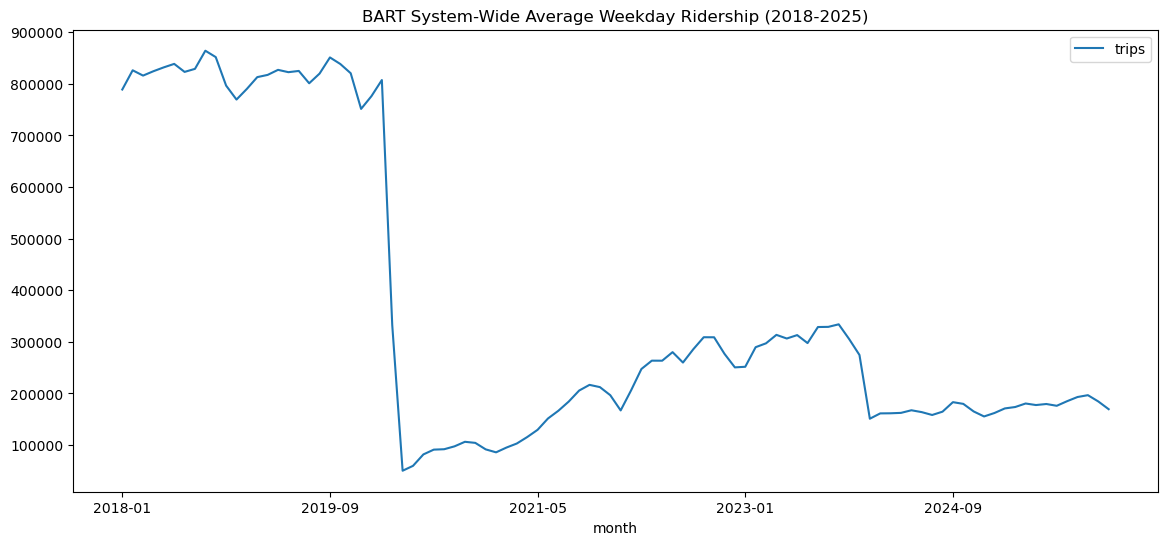

In [43]:
aggregated_df.plot(x = "month", y = "trips", figsize = (14,6), title = "BART System-Wide Average Weekday Ridership (2018-2025)")

noticed a drop from 2023 to 2024.

Recovery Analysis:

Baseline definition: Average of Jan 2018 – Feb 2020 (the full pre-COVID window).
Rationale: Using a two-year average reduces noise from any single month and 
captures BART's typical pre-pandemic ridership more reliably than Feb 2020 alone.

Disclosure, there is a sudden drop from 2023 to 2024, however it was due to a methodology change by BART

In [44]:
pre_covid = all_data[all_data["month"].between('2018-01', '2020-02')]
baseline_df = pre_covid.groupby('origin')['trips'].sum()
baseline_df = baseline_df / 26
baseline_df.sort_values(ascending=False).head(10)

origin
MT   85,524
EM   82,030
PL   58,541
CC   48,992
12   27,293
19   26,753
16   25,362
24   24,852
BP   22,622
BK   21,570
Name: trips, dtype: float64

In [45]:
monthly_origin = all_data.groupby(["origin", "month"])["trips"].sum().reset_index()

In [46]:
monthly_origin = monthly_origin[["origin", "trips", "month"]]
monthly_origin.head()

,origin,trips,month
0,12,"26,187",2018-01
1,12,"27,316",2018-02
2,12,"26,732",2018-03
3,12,"26,637",2018-04
4,12,"27,670",2018-05


In [47]:
print(monthly_origin.shape)


(4784, 3)


In [48]:
recovery_df = monthly_origin.merge(baseline_df, on='origin', suffixes=('_current', '_baseline'))
recovery_df.head()

,origin,trips_current,month,trips_baseline
0,12,"26,187",2018-01,"27,293"
1,12,"27,316",2018-02,"27,293"
2,12,"26,732",2018-03,"27,293"
3,12,"26,637",2018-04,"27,293"
4,12,"27,670",2018-05,"27,293"


In [49]:
pd.options.display.float_format = '{:.3f}'.format
recovery_df['recovery_index'] = recovery_df['trips_current'] / recovery_df['trips_baseline']
recovery_df = recovery_df[recovery_df['trips_baseline'] > 0]
recovery_df.head(100)

,origin,trips_current,month,trips_baseline,recovery_index
0,12,26186.524,2018-01,27293.063,0.959
1,12,27316.263,2018-02,27293.063,1.001
2,12,26732.273,2018-03,27293.063,0.979
3,12,26637.429,2018-04,27293.063,0.976
4,12,27669.682,2018-05,27293.063,1.014
...,...,...,...,...,...
95,12,5161.000,2025-12,27293.063,0.189
96,16,23914.571,2018-01,25361.947,0.943
97,16,24957.368,2018-02,25361.947,0.984
98,16,24425.091,2018-03,25361.947,0.963


Recovery Index

The recovery index measures each station's monthly ridership as a fraction 
of its pre-COVID baseline (Jan 2018 – Feb 2020 average). A value of 1.0 means the station is back to baseline. Values above 1.0 mean it exceeded 
baseline; below 1.0 means it hasn't fully recovered.

Pre-COVID months (2018 – Feb 2020) naturally cluster near 1.0 with small 
seasonal variation — January tends to be slightly below baseline, summer months slightly above. The meaningful story starts in March 2020.


In [50]:
sys_wide_df = recovery_df.groupby("month")["recovery_index"].mean().reset_index()
sys_wide_df

,month,recovery_index
0,2018-01,0.980
1,2018-02,1.028
2,2018-03,1.018
3,2018-04,1.030
4,2018-05,1.003
...,...,...
91,2025-08,0.236
92,2025-09,0.246
93,2025-10,0.249
94,2025-11,0.233


<Axes: title={'center': 'BART System-Wide Recovery Index (2018-2025'}, xlabel='month'>

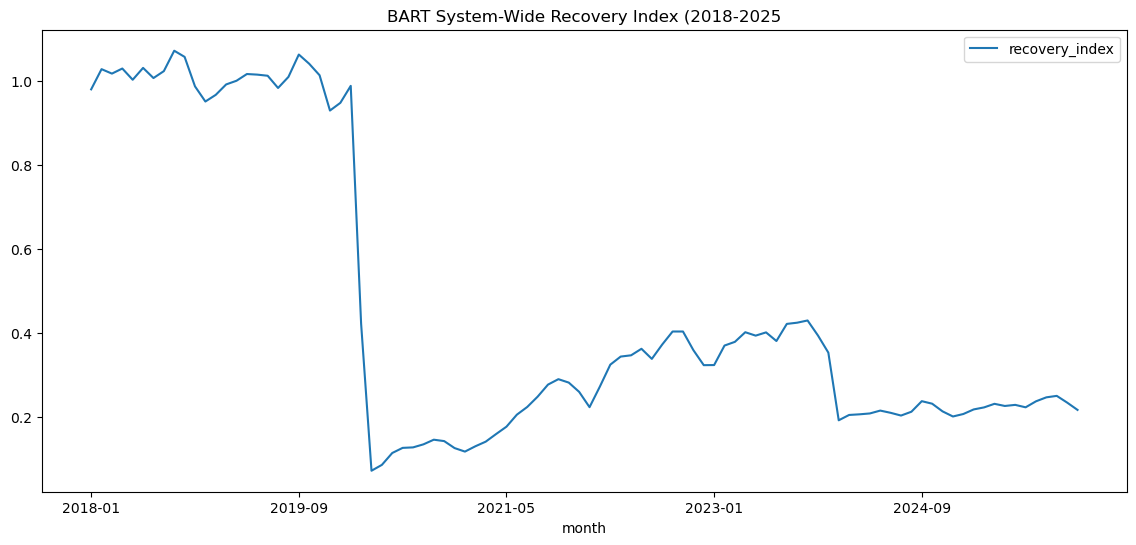

In [51]:
sys_wide_df.plot(x = "month", y = "recovery_index", figsize = (14,6), title = "BART System-Wide Recovery Index (2018-2025")

In [52]:
### y-axis changed from trips to recovery index

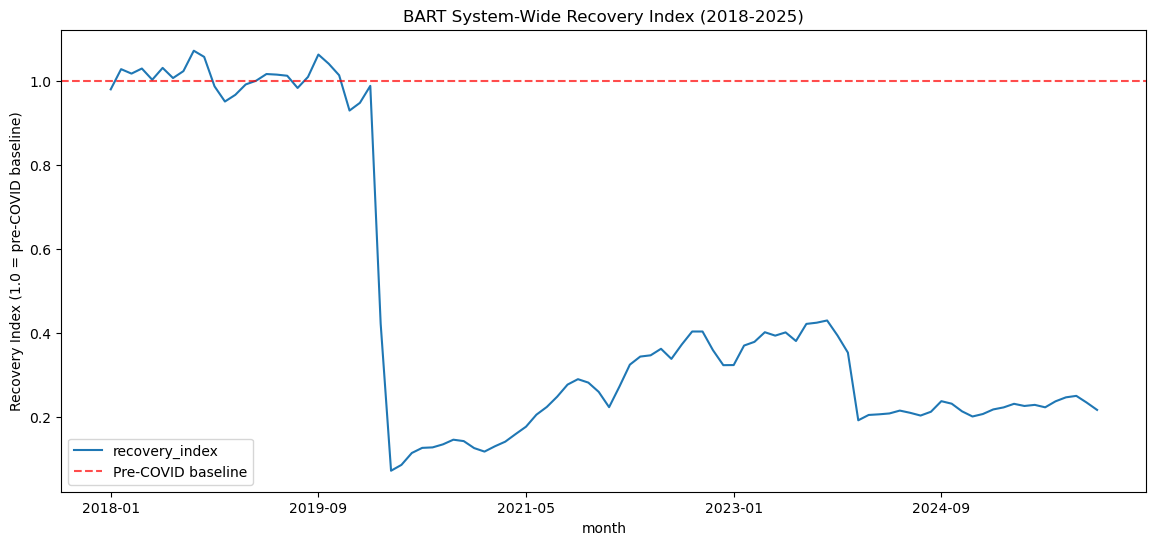

In [53]:
ax = sys_wide_df.plot(x='month', y='recovery_index', figsize=(14,6),
                      title='BART System-Wide Recovery Index (2018-2025)')
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Pre-COVID baseline')
ax.set_ylabel('Recovery Index (1.0 = pre-COVID baseline)')
ax.legend()

In [54]:
### Between 2023 and early 2024, there was a methodology break in how BART measures trips

In [55]:
recovery_filtered = recovery_df[recovery_df["month"] == "2023-12"].sort_values(by = "recovery_index", ascending = False)
recovery_filtered

,origin,trips_current,month,trips_baseline,recovery_index
451,AN,2962.905,2023-12,4728.312,0.627
4183,SO,6752.429,2023-12,12552.834,0.538
3703,RM,4073.905,2023-12,8754.838,0.465
3415,PC,918.190,2023-12,1977.605,0.464
4087,SL,5341.524,2023-12,12230.827,0.437
3131,OA,1135.524,2023-12,2709.400,0.419
2079,FV,6414.238,2023-12,15521.844,0.413
735,BF,4263.476,2023-12,10818.154,0.394
2367,LF,2694.571,2023-12,6852.727,0.393
3607,PL,23015.429,2023-12,58541.082,0.393


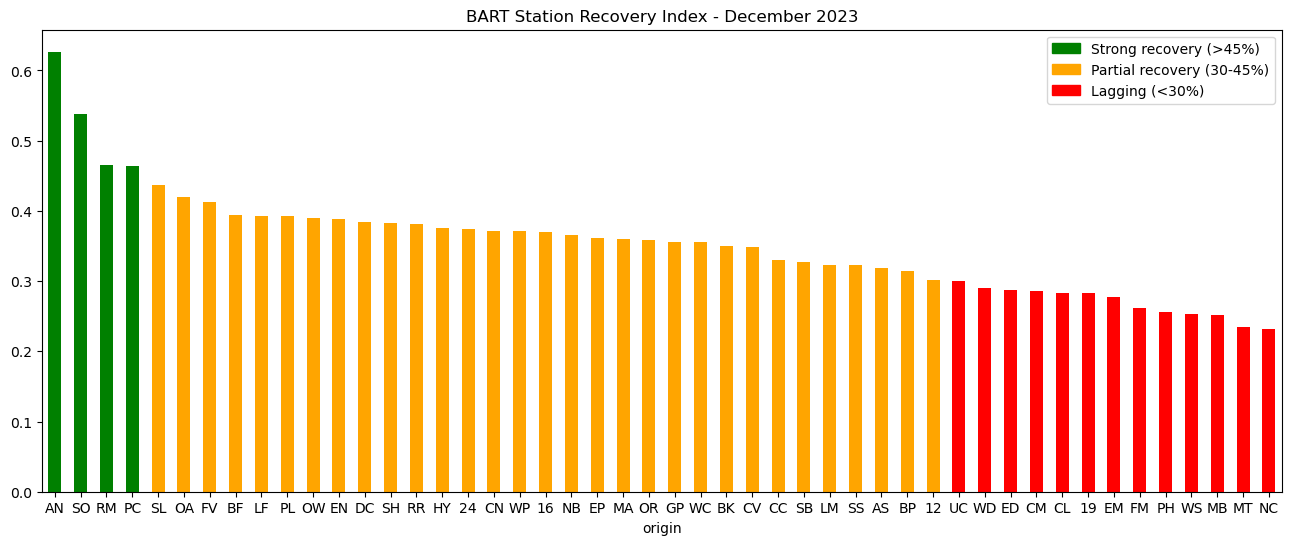

In [56]:
import matplotlib.patches as mpatches

colors = ['green' if x > 0.45 else 'orange' if x > 0.30 else 'red' 
          for x in recovery_filtered["recovery_index"]]

recovery_filtered.plot(x = "origin", y = "recovery_index", 
                       kind = "bar", figsize = (16,6), 
                       title = "BART Station Recovery Index - December 2023", 
                       rot = 0, 
                       color = colors, 
                       legend = True
)

green_patch = mpatches.Patch(color='green', label='Strong recovery (>45%)')
orange_patch = mpatches.Patch(color='orange', label='Partial recovery (30-45%)')
red_patch = mpatches.Patch(color='red', label='Lagging (<30%)')

plt.legend(handles=[green_patch, orange_patch, red_patch])
plt.show()



### Phase 4: Demographic Layer

The demographics behind every BART station could help determine "who" rides the BART on a daily basis. Initial prediction is that essential workers and tech workers primarily take the BART to major metropolitan centers such as San Francisco

Data regarding income, employment industry, and population will come from the BART Station Profile. Nearby neighborhoods and zipcodes within a 5-10 mile radius of a BART Station will also be included in the analysis

Prediction: Stations serving high-income, tech-heavy neighborhoods are expected to show lower recovery rates, as remote work disproportionately affected those commuters.

In [57]:

conn = sqlite3.connect(":memory:")
stations.to_sql("stations", conn, index = False, if_exists = "replace")

station_alphabetical_query = """
SELECT "Two-Letter Station Code", "Station Name"
FROM stations
ORDER BY "Station Name" ASC
"""
result = pd.read_sql_query(station_alphabetical_query, conn)
result.to_csv('../Data/raw/station_crosswalk.csv', index=False)

In [58]:
#HHI = House-Hold Income
pd.options.display.float_format = '{:.3f}'.format
station_profile_df = pd.read_excel("../Data/raw/station_profile_2024.xlsx", sheet_name = "HHI reduced categories", skiprows = 7)
station_profile_df.columns = ["Entry Station", "sample size", "pct_<50k", "pct_50k-99k", "pct_>100k"]

station_profile_df["pct_<50k"] = station_profile_df["pct_<50k"] * 100
station_profile_df["pct_50k-99k"] = station_profile_df["pct_50k-99k"] * 100
station_profile_df["pct_>100k"] = station_profile_df["pct_>100k"] * 100
station_profile_df.head(10)



,Entry Station,sample size,pct_<50k,pct_50k-99k,pct_>100k
0,12th Street / Oakland City Center,297,22.204,27.942,49.854
1,16th Street / Mission,439,18.588,30.449,50.963
2,19th Street Oakland,368,18.006,32.688,49.306
3,24th Street / Mission,529,16.180,25.627,58.193
4,Antioch,424,17.947,35.248,46.806
5,Ashby,370,23.122,26.320,50.558
6,Balboa Park,460,29.806,29.968,40.225
7,Bay Fair,292,22.946,36.828,40.226
8,Berryessa / North San Jose,277,23.463,29.591,46.946
9,Castro Valley,232,12.115,30.050,57.835


In [59]:
station_profile_df.tail(5)

,Entry Station,sample size,pct_<50k,pct_50k-99k,pct_>100k
51,NaN,NaN,NaN,NaN,NaN
52,NaN,NaN,HOUSEHOLD INCOMEHOUSEHOLD INCOMEHOUSEHOLD INCO...,NaN,NaN
53,NaN,NaN,"Under $50,000Under $50,000Under $50,000Under $...","$50,000-$99,999$50,000-$99,999$50,000-$99,999$...","$100,000 and above$100,000 and above$100,000 a..."
54,TOTAL ORIGINS,n,Row %Row %Row %Row %Row %Row %Row %Row %Row %R...,Row %Row %Row %Row %Row %Row %Row %Row %Row %R...,Row %Row %Row %Row %Row %Row %Row %Row %Row %R...
55,Systemwide (all stations),29281,22.168,28.304,49.528


In [60]:
print(station_profile_df.shape)

(56, 5)


In [61]:
station_profile_df = station_profile_df.dropna(subset=['Entry Station'])
station_profile_df.shape
station_profile_df.tail(5)

,Entry Station,sample size,pct_<50k,pct_50k-99k,pct_>100k
46,West Dublin / Pleasanton,247,7.608,16.270,76.122
47,West Oakland,528,20.831,26.681,52.488
50,Systemwide Data\nBase: Total origins\nWeight: ...,NaN,NaN,NaN,NaN
54,TOTAL ORIGINS,n,Row %Row %Row %Row %Row %Row %Row %Row %Row %R...,Row %Row %Row %Row %Row %Row %Row %Row %Row %R...,Row %Row %Row %Row %Row %Row %Row %Row %Row %R...
55,Systemwide (all stations),29281,22.168,28.304,49.528


In [62]:
station_profile_df = station_profile_df[pd.to_numeric(station_profile_df['sample size'], errors='coerce').notna()]
station_profile_df.shape
station_profile_df.tail(5)

,Entry Station,sample size,pct_<50k,pct_50k-99k,pct_>100k
44,Walnut Creek,393,10.867,23.090,66.043
45,Warm Springs / South Fremont,151,9.245,27.731,63.024
46,West Dublin / Pleasanton,247,7.608,16.270,76.122
47,West Oakland,528,20.831,26.681,52.488
55,Systemwide (all stations),29281,22.168,28.304,49.528


In [63]:
station_profile_df = station_profile_df[station_profile_df['Entry Station'] != 'Systemwide (all stations)']
station_profile_df.shape

(48, 5)

Joining Demographic Data

Using BART's 2024 Station Profile Study to attach rider income demographics 
to each station. The key variable is `pct_>100k` — the percentage of riders 
earning $100,000+ — as a proxy for white-collar/tech workers who were most 
likely to shift to remote work post-COVID.

Join strategy: Station Profile data uses full station names while 
recovery_df uses two-letter codes. The stations lookup table bridges the two.

Limitation: Demographics are from 2024, post-recovery period. Station 
demographic profiles are assumed relatively stable, though gentrification 
in areas like Oakland and the Mission may have shifted some station profiles 
since 2018-2019.

In [64]:
stations.head()

,Two-Letter Station Code,Station Name
0,RM,Richmond
1,EN,El Cerrito Del Norte
2,EP,El Cerrito Plaza
3,NB,North Berkeley
4,BK,Berkeley


In [65]:
profile_c_names = set(station_profile_df['Entry Station'])
bart_names = set(stations['Station Name'])

print("In profile but not in stations:", profile_c_names - bart_names)
print("In stations but not in profile:", bart_names - profile_c_names)

#inconsistent naming conventions between bart files 

In profile but not in stations: {'Warm Springs / South Fremont', 'Bay Fair', 'Pittsburg / Bay Point', 'North Berkeley alt', 'West Dublin / Pleasanton', 'Pleasant Hill / Contra Costa Centre', 'Downtown Berkeley', 'Berryessa / North San Jose', 'El Cerrito del Norte', 'Dublin / Pleasanton', '16th Street / Mission', 'North Concord / Martinez', '24th Street / Mission', 'Civic Center / UN Plaza'}
In stations but not in profile: {'North Concord', 'Berryessa / North San José', 'El Cerrito Del Norte', 'North Berkeley', 'Civic Center', 'San Francisco International Airport', 'Pittsburg/Bay Point', '24th Street Mission', 'Warm Springs', '16th Street Mission', 'Berkeley', 'West Dublin/Pleasanton', 'Dublin/Pleasanton', 'Bayfair', 'Pleasant Hill', 'Oakland International Airport'}


In [66]:
name_mapping = {
    'Pittsburg / Bay Point': 'Pittsburg/Bay Point',
    'North Concord / Martinez': 'North Concord',
    'Pleasant Hill / Contra Costa Centre': 'Pleasant Hill',
    'Berryessa / North San Jose': 'Berryessa / North San José',
    'Dublin / Pleasanton': 'Dublin/Pleasanton',
    'Bay Fair': 'Bayfair',
    '16th Street / Mission': '16th Street Mission',
    'Civic Center / UN Plaza': 'Civic Center',
    'Downtown Berkeley': 'Berkeley',
    'El Cerrito del Norte': 'El Cerrito Del Norte',
    '24th Street / Mission': '24th Street Mission',
    'North Berkeley alt': 'North Berkeley',
    'West Dublin / Pleasanton': 'West Dublin/Pleasanton',
    'Warm Springs / South Fremont': 'Warm Springs'
}

station_profile_df['Entry Station'] = station_profile_df['Entry Station'].replace(name_mapping)

In [67]:
station_profile_df.head()

,Entry Station,sample size,pct_<50k,pct_50k-99k,pct_>100k
0,12th Street / Oakland City Center,297,22.204,27.942,49.854
1,16th Street Mission,439,18.588,30.449,50.963
2,19th Street Oakland,368,18.006,32.688,49.306
3,24th Street Mission,529,16.180,25.627,58.193
4,Antioch,424,17.947,35.248,46.806


In [68]:
profile_names = set(station_profile_df['Entry Station'])
bart_names = set(stations['Station Name'])

print("In profile but not in stations:", profile_names - bart_names)
print("In stations but not in profile:", bart_names - profile_names)

In profile but not in stations: set()
In stations but not in profile: {'San Francisco International Airport', 'Oakland International Airport'}


In [69]:
profile_with_codes = station_profile_df.merge(
    stations,
    left_on = "Entry Station",
    right_on = "Station Name"
)
profile_with_codes.head()

,Entry Station,sample size,pct_<50k,pct_50k-99k,pct_>100k,Two-Letter Station Code,Station Name
0,12th Street / Oakland City Center,297,22.204,27.942,49.854,12,12th Street / Oakland City Center
1,16th Street Mission,439,18.588,30.449,50.963,16,16th Street Mission
2,19th Street Oakland,368,18.006,32.688,49.306,19,19th Street Oakland
3,24th Street Mission,529,16.180,25.627,58.193,24,24th Street Mission
4,Antioch,424,17.947,35.248,46.806,AN,Antioch


In [70]:
phase4_df = recovery_df.merge(
    profile_with_codes,
    left_on='origin',
    right_on='Two-Letter Station Code'
)
phase4_df.head()

,origin,trips_current,month,trips_baseline,recovery_index,Entry Station,sample size,pct_<50k,pct_50k-99k,pct_>100k,Two-Letter Station Code,Station Name
0,AN,713.727,2018-05,4728.312,0.151,Antioch,424,17.947,35.248,46.806,AN,Antioch
1,AN,5667.905,2018-06,4728.312,1.199,Antioch,424,17.947,35.248,46.806,AN,Antioch
2,AN,5583.905,2018-07,4728.312,1.181,Antioch,424,17.947,35.248,46.806,AN,Antioch
3,AN,5683.217,2018-08,4728.312,1.202,Antioch,424,17.947,35.248,46.806,AN,Antioch
4,AN,6029.684,2018-09,4728.312,1.275,Antioch,424,17.947,35.248,46.806,AN,Antioch


In [71]:
station_recovery_2023 = phase4_df[phase4_df['month'] == '2023-12'].copy()
station_recovery_2023.head()

,origin,trips_current,month,trips_baseline,recovery_index,Entry Station,sample size,pct_<50k,pct_50k-99k,pct_>100k,Two-Letter Station Code,Station Name
67,AN,2962.905,2023-12,4728.312,0.627,Antioch,424,17.947,35.248,46.806,AN,Antioch
163,AS,3287.000,2023-12,10320.528,0.318,Ashby,370,23.122,26.320,50.558,AS,Ashby
259,BF,4263.476,2023-12,10818.154,0.394,Bayfair,292,22.946,36.828,40.226,BF,Bayfair
355,BK,7537.000,2023-12,21569.774,0.349,Berkeley,215,25.441,27.068,47.491,BK,Berkeley
451,BP,7125.667,2023-12,22621.527,0.315,Balboa Park,460,29.806,29.968,40.225,BP,Balboa Park


<Axes: title={'center': 'Recovery Index vs. High Income Riders (Dec 2023)'}, xlabel='pct_>100k', ylabel='recovery_index'>

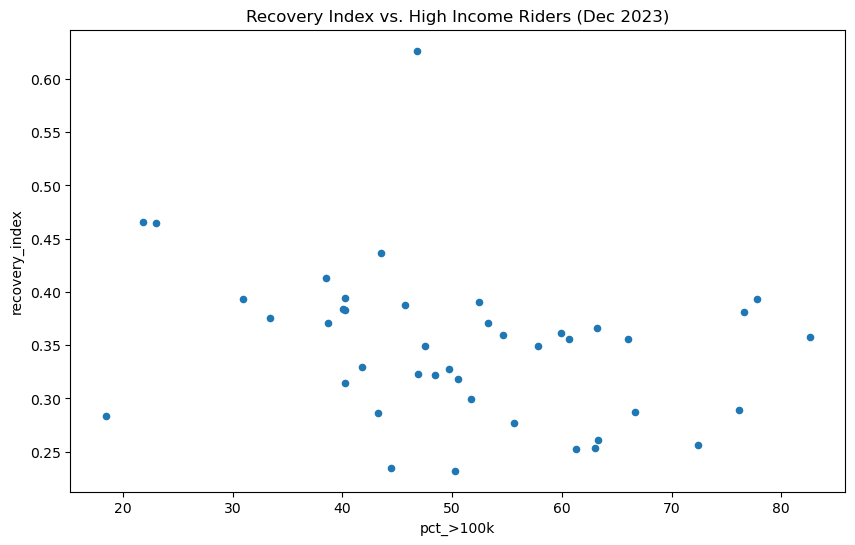

In [72]:
station_recovery_2023.plot(
    x='pct_>100k',
    y='recovery_index',
    kind='scatter',
    figsize=(10, 6),
    title='Recovery Index vs. High Income Riders (Dec 2023)'
)

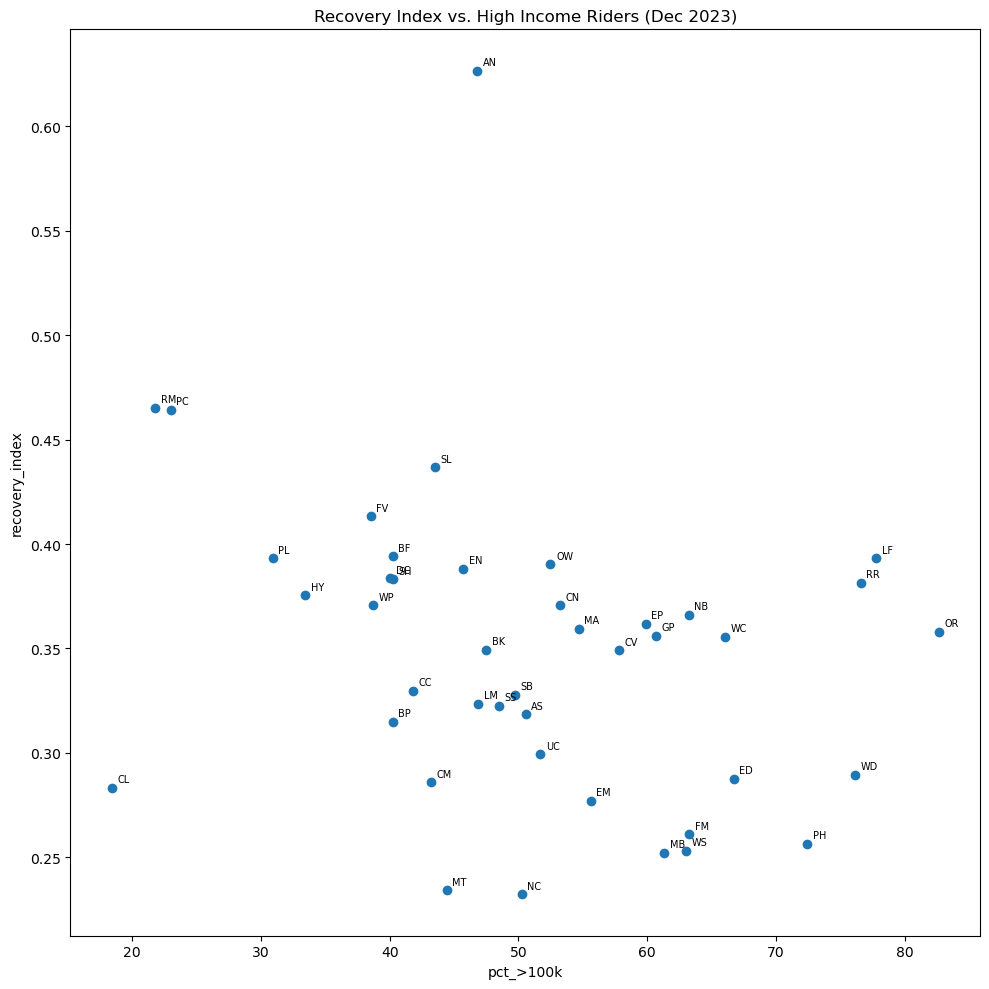

In [73]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(station_recovery_2023['pct_>100k'], station_recovery_2023['recovery_index'])

# Label each dot with the station name
for _, row in station_recovery_2023.iterrows():
    ax.annotate(row['Two-Letter Station Code'], 
                (row['pct_>100k'], row['recovery_index']),
                fontsize=7, 
                xytext=(4, 4), 
                textcoords='offset points')

ax.set_xlabel('pct_>100k')
ax.set_ylabel('recovery_index')
ax.set_title('Recovery Index vs. High Income Riders (Dec 2023)')
plt.tight_layout()
plt.show()

Contrary to the previous predictions, there is no meaningful correlation between the share of high income riders and post-COVID recovery. Stations across the income spectrum are recovering at similar rates, suggesting that remote work adoption by high-income workers did not disproportionately suppress ridership at wealthier stations. There are some outliers worth noting such as RM and PC show relatively strong recovery despite having among the lowest shares of high-income riders, while CL sits near the bottom in both income share and recovery. These may reflect local factors such as land use, connecting bus service, or station-area development rather than rider demographics.

Population Density

Testing population density as a second demographic predictor of recovery, 
alongside the income analysis above.

**Hypothesis:** High-density urban stations retain more transit-dependent 
riders, while low-density suburban stations are more vulnerable to remote 
work disruption.

**Data source:** U.S. Census Bureau, ACS 5-Year Estimates, Table B01003 
(Total Population) by ZIP Code Tabulation Area. Density calculated as 
population per square mile using Census land area data.

In [74]:
pop_df = pd.read_csv("../Data/raw/population_zipcode_data_2023/ACSDT5Y2023.B01003-Data.csv", header = 0, skiprows = [1])

pop_df["zip"] = pop_df["NAME"].str.extract(r"(\d{5})")

pop_df = pop_df[["zip", "B01003_001E"]].rename(columns={"B01003_001E": "population"})

gaz = pd.read_csv("../Data/raw/2023_Gaz_zcta_national.txt", 
                  sep="\t", dtype={"GEOID": str})
gaz = gaz[["GEOID", "ALAND_SQMI"]].rename(columns={"GEOID": "zip", "ALAND_SQMI": "land_sqmi"})

density_df = pop_df.merge(gaz, on = "zip")
density_df["pop_density"] = density_df["population"].astype(float) / density_df["land_sqmi"]

density_df.head()

,zip,population,land_sqmi,pop_density
0,89010,355,384.310,0.924
1,89019,2355,499.569,4.714
2,89060,12783,449.434,28.442
3,89061,7835,64.037,122.351
4,89439,2071,16.261,127.360


In [75]:
station_recovery_2023.columns

Index(['origin', 'trips_current', 'month', 'trips_baseline', 'recovery_index',
       'Entry Station', 'sample size', 'pct_<50k', 'pct_50k-99k', 'pct_>100k',
       'Two-Letter Station Code', 'Station Name'],
      dtype='object')

In [76]:
pd.read_csv("../Data/raw/station_crosswalk.csv").head()

,Two-Letter Station Code,Station Name
0,12,12th Street / Oakland City Center
1,16,16th Street Mission
2,19,19th Street Oakland
3,24,24th Street Mission
4,AN,Antioch


In [77]:
#from claude to manually add zipcodes to the file
station_zips = {
    '12': '94612', '16': '94103', '19': '94612', '24': '94110',
    'AN': '94509', 'AS': '94710', 'BA': '94501', 'BF': '94578',
    'BK': '94710', 'BL': '94010', 'BP': '94112', 'BW': '94598',
    'CC': '94523', 'CL': '94015', 'CM': '94519', 'CN': '94520',
    'CV': '94546', 'DA': '94568', 'DC': '94568', 'DP': '94568',
    'DT': '94568', 'ED': '94621', 'EM': '94608', 'EN': '94608',
    'EP': '94530', 'FV': '94541', 'GC': '94080', 'GP': '94530',
    'HY': '94544', 'LF': '94550', 'LM': '94577', 'MA': '94601',
    'MB': '94539', 'MC': '94103', 'ML': '94030', 'MT': '94103',
    'NB': '94805', 'NC': '94520', 'NL': '94612', 'OA': '94621',
    'OR': '94619', 'OW': '94607', 'PC': '94565', 'PH': '94588',
    'PL': '94523', 'RM': '94801', 'RR': '94577', 'SB': '94577',
    'SF': '94128', 'SL': '94577', 'SM': '94402', 'SS': '94577',
    'UC': '94587', 'WC': '94596', 'WD': '94568', 'WP': '94564',
    'WS': '94538'
}

station_zip_df = pd.DataFrame(list(station_zips.items()), 
                               columns=['Two-Letter Station Code', 'zip'])

In [78]:
station_zip_df.head()

,Two-Letter Station Code,zip
0,12,94612
1,16,94103
2,19,94612
3,24,94110
4,AN,94509


In [79]:
station_recovery_2023 = phase4_df[phase4_df['month'] == '2023-12'].copy()
station_recovery_2023 = station_recovery_2023.merge(station_zip_df, on='Two-Letter Station Code')
station_recovery_2023 = station_recovery_2023.merge(density_df[['zip', 'pop_density']], on='zip')

station_recovery_2023[['Two-Letter Station Code', 'zip', 'pop_density', 'recovery_index']].head(10)

,Two-Letter Station Code,zip,pop_density,recovery_index
0,AN,94509,4070.913,0.627
1,AS,94710,3770.370,0.318
2,BF,94578,9117.570,0.394
3,BK,94710,3770.370,0.349
4,BP,94112,24027.886,0.315
5,CC,94523,4827.782,0.330
6,CL,94015,11336.810,0.283
7,CM,94519,4391.093,0.286
8,CN,94520,3724.372,0.371
9,CV,94546,2873.222,0.349


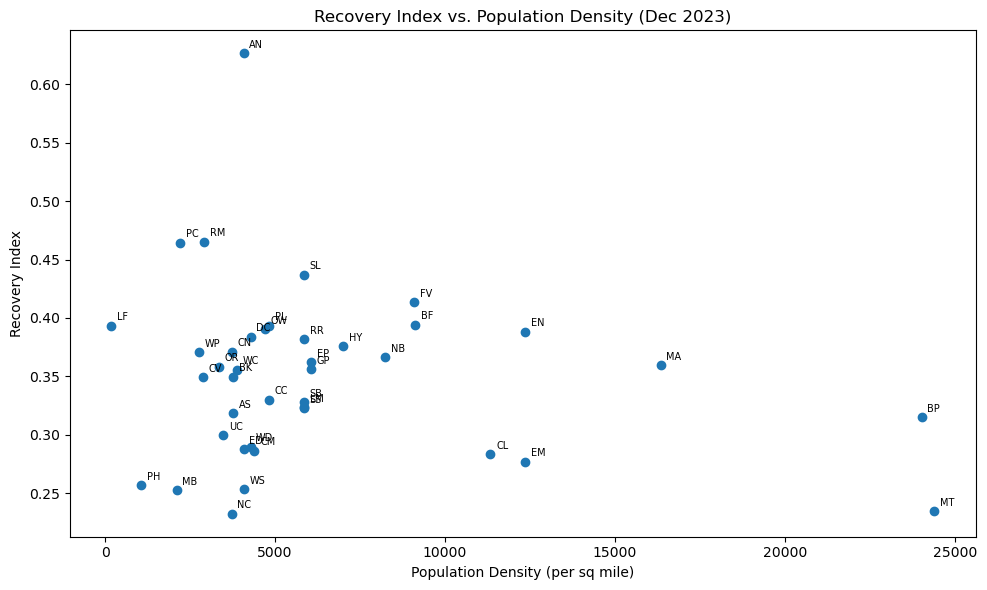

In [80]:
fig, ax = plt.subplots(figsize = (10,6))
ax.scatter(station_recovery_2023["pop_density"], station_recovery_2023["recovery_index"])

for _, row in station_recovery_2023.iterrows():
    ax.annotate(row["Two-Letter Station Code"],(row["pop_density"], row["recovery_index"]), fontsize=7, xytext=(4, 4), textcoords = "offset points")

ax.set_xlabel("Population Density (per sq mile)")
ax.set_ylabel("Recovery Index")
ax.set_title("Recovery Index vs. Population Density (Dec 2023)")
plt.tight_layout()
plt.show()

**Phase 4 Conclusion**

Neither high-income ridership nor population density meaningfully predicts post-COVID recovery. The densest urban stations (BP, MT) and the more affluent stations show similar or worse recovery compared to mid-density suburban stations. Antioch (AN) remains the standout outlier - a low-density suburban terminus with the highest recovery in the system, suggesting station-specific factors like park-and-ride capacity from commuters from nearby suburbs and cities in the Sacramento-Joaquin Delta like Brentwood. This might also serve as an essential worker corridor rather than just demographics alone. 

**Phase 5: BART Station Extension Analysis**

**Proposed corridors:**
BART has several stations planned such as the:

- **VTA Silicon Valley (4 stations)**: Dense, high-income, tech-adjacent
    - 28th St/Little Portugal
    - Downtown San Jose
    - Diridon
    - Santa Clara

- **East Bay (2 stations)**: Suburban to infill
    - Livermore (Isabel Station)
    - Irvington

- **Contra Costa/eBART (7 stations)**: Low-density, park-and-ride dependent
    - Laurel Road
    - Lone Tree Way 
    - Mokelumne Trail 
    - Sand Creek Road 
    - Balfour Road 
    - Discovery Bay/Byron


**Hypothesis**: Silicon Valley Stations will cluster with high-income and population_density like stations but could underperform due to remote work. Future Contra Costa stations will cluster with Antioch (AN) and show stronger recovery. However, as more stations open along the SR-4 corridor 
into the San Joaquin Delta, Antioch's ridership dominance may diminish as 
trips distribute across new stations, changing the dynamics of the eastern 
corridor entirely.



In [81]:
proposed_stations = {
    'station': [
        '28th St/Little Portugal', 'Downtown San Jose', 'Diridon', 'Santa Clara',
        'Livermore (Isabel)', 'Irvington',
        'Pittsburg Center', 'Laurel Road', 'Lone Tree Way', 'Mokelumne Trail',
        'Sand Creek Road', 'Balfour Road', 'Discovery Bay/Byron'
    ],
    'corridor': [
        'VTA Silicon Valley', 'VTA Silicon Valley', 'VTA Silicon Valley', 'VTA Silicon Valley',
        'East Bay', 'East Bay',
        'Contra Costa', 'Contra Costa', 'Contra Costa', 'Contra Costa',
        'Contra Costa', 'Contra Costa', 'Contra Costa'
    ],
    'zip': [
        '95116', '95113', '95110', '95050',
        '94550', '94539',
        '94565', '94531', '94509', '94513',
        '94513', '94513', '94505'
    ]
}

proposed_df = pd.DataFrame(proposed_stations)
proposed_df.head()

,station,corridor,zip
0,28th St/Little Portugal,VTA Silicon Valley,95116
1,Downtown San Jose,VTA Silicon Valley,95113
2,Diridon,VTA Silicon Valley,95110
3,Santa Clara,VTA Silicon Valley,95050
4,Livermore (Isabel),East Bay,94550


In [82]:
proposed_df = pd.DataFrame(proposed_stations)
proposed_df = proposed_df.merge(density_df[["zip", "pop_density"]], on = "zip")
proposed_df

,station,corridor,zip,pop_density
0,28th St/Little Portugal,VTA Silicon Valley,95116,13696.970
1,Downtown San Jose,VTA Silicon Valley,95113,7020.115
2,Diridon,VTA Silicon Valley,95110,4277.167
3,Santa Clara,VTA Silicon Valley,95050,7301.008
4,Livermore (Isabel),East Bay,94550,182.406
5,Irvington,East Bay,94539,2098.066
6,Pittsburg Center,Contra Costa,94565,2206.367
7,Laurel Road,Contra Costa,94531,3189.763
8,Lone Tree Way,Contra Costa,94509,4070.913
9,Mokelumne Trail,Contra Costa,94513,864.349


In [83]:
station_recovery_2023[["Two-Letter Station Code", "pop_density"]].sort_values("pop_density", ascending=False)

,Two-Letter Station Code,pop_density
22,MT,24398.836
4,BP,24027.886
20,MA,16345.420
13,EN,12353.924
12,EM,12353.924
6,CL,11336.810
2,BF,9117.570
15,FV,9091.336
23,NB,8233.780
17,HY,7006.848


In [84]:
proposed_pop_df = pd.read_csv("../Data/raw/ACSDT5Y2023.B19013_2026-05-10T184226/ACSDT5Y2023.B19013-Data.csv", 
                     header=0, skiprows=[1])

proposed_df = pd.DataFrame(proposed_stations)
proposed_df = proposed_df.merge(density_df[["zip", "pop_density"]], on = "zip")
proposed_df

proposed_pop_df["zip"] = proposed_pop_df["NAME"].str.extract(r"(\d{5})")
proposed_pop_df = proposed_pop_df[["zip", "B19013_001E"]].rename(columns={"B19013_001E": "Median-Household Income (MHI)"})
proposed_pop_df.head()

,zip,Median-Household Income (MHI)
0,NaN,78538


In [85]:
proposed_pop_df = pd.read_csv("../Data/raw/ACSDT5Y2023.B19013_2026-05-10T184226/ACSDT5Y2023.B19013-Data.csv", 
                     header=0, skiprows=[1])
print(proposed_pop_df.shape)
proposed_pop_df["NAME"].head(10)

(1, 5)


0    United States
Name: NAME, dtype: object

In [86]:
mhi_lookup = {
    "95116": "$85,818",  # 28th St/Little Portugal
    "95113": "$151,685.",  # Downtown San Jose
    "95110": "$131,491",  # Diridon
    "95050": "$130,051",  # Santa Clara
    "94550": "$153,602",  # Livermore (Isabel)
    "94539": "$243,552",  # Irvington
    "94565": "$101,099",  # Pittsburg Center exists but using for comparision for Contra Costa Stations
    "94531": "$94,256",   # Laurel Road
    "94509": "$109,673",  # Lone Tree Way
    "94513": "$139,567",  # Brentwood stations
    "94505": "$146,480",  # Discovery Bay/Byron
}

In [87]:
proposed_df["mhi"] = proposed_df["zip"].map(mhi_lookup)
proposed_df

,station,corridor,zip,pop_density,mhi
0,28th St/Little Portugal,VTA Silicon Valley,95116,13696.970,"$85,818"
1,Downtown San Jose,VTA Silicon Valley,95113,7020.115,"$151,685."
2,Diridon,VTA Silicon Valley,95110,4277.167,"$131,491"
3,Santa Clara,VTA Silicon Valley,95050,7301.008,"$130,051"
4,Livermore (Isabel),East Bay,94550,182.406,"$153,602"
5,Irvington,East Bay,94539,2098.066,"$243,552"
6,Pittsburg Center,Contra Costa,94565,2206.367,"$101,099"
7,Laurel Road,Contra Costa,94531,3189.763,"$94,256"
8,Lone Tree Way,Contra Costa,94509,4070.913,"$109,673"
9,Mokelumne Trail,Contra Costa,94513,864.349,"$139,567"


In [88]:
proposed_df["mhi"] = proposed_df["mhi"].str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)
proposed_df

,station,corridor,zip,pop_density,mhi
0,28th St/Little Portugal,VTA Silicon Valley,95116,13696.970,85818.000
1,Downtown San Jose,VTA Silicon Valley,95113,7020.115,151685.000
2,Diridon,VTA Silicon Valley,95110,4277.167,131491.000
3,Santa Clara,VTA Silicon Valley,95050,7301.008,130051.000
4,Livermore (Isabel),East Bay,94550,182.406,153602.000
5,Irvington,East Bay,94539,2098.066,243552.000
6,Pittsburg Center,Contra Costa,94565,2206.367,101099.000
7,Laurel Road,Contra Costa,94531,3189.763,94256.000
8,Lone Tree Way,Contra Costa,94509,4070.913,109673.000
9,Mokelumne Trail,Contra Costa,94513,864.349,139567.000


In [89]:
mhi_df = pd.read_csv("../Data/raw/ACSDT5Y2023.B19013_2026-05-10T184226/ACSDT5Y2023.B19013-Data.csv", 
                     header=0, skiprows=[1])
print(mhi_df.shape)
mhi_df.head()

(1, 5)


,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,0100000US,United States,78538,176,NaN


In [90]:
station_zip_df["zip"].unique()

array(['94612', '94103', '94110', '94509', '94710', '94501', '94578',
       '94010', '94112', '94598', '94523', '94015', '94519', '94520',
       '94546', '94568', '94621', '94608', '94530', '94541', '94080',
       '94544', '94550', '94577', '94601', '94539', '94030', '94805',
       '94619', '94607', '94565', '94588', '94801', '94128', '94402',
       '94587', '94596', '94564', '94538'], dtype=object)

In [91]:
import requests

zips = ",".join(station_zip_df["zip"].unique())
url = f"https://api.census.gov/data/2023/acs/acs5?get=NAME,B19013_001E&for=zip%20code%20tabulation%20area:{zips.replace(',', ',')}"
response = requests.get(url)
print(response.status_code)
print(response.text[:500])

200
[["NAME","B19013_001E","zip code tabulation area"],
["ZCTA5 94010","191758","94010"],
["ZCTA5 94015","123552","94015"],
["ZCTA5 94030","157567","94030"],
["ZCTA5 94080","135966","94080"],
["ZCTA5 94103","122339","94103"],
["ZCTA5 94110","152403","94110"],
["ZCTA5 94112","130906","94112"],
["ZCTA5 94128","-666666666","94128"],
["ZCTA5 94402","179683","94402"],
["ZCTA5 94501","119500","94501"],
["ZCTA5 94509","81512","94509"],
["ZCTA5 94519","123366","94519"],
["ZCTA5 94520","79790","94520"],
["ZC


In [92]:
import json

data = json.loads(response.text)
mhi_existing_df = pd.DataFrame(data[1:], columns=["name", "mhi", "zip"])
mhi_existing_df["mhi"] = pd.to_numeric(mhi_existing_df["mhi"], errors = "coerce")
mhi_existing_df = mhi_existing_df[["zip", "mhi"]]
mhi_existing_df.head()

,zip,mhi
0,94010,191758
1,94015,123552
2,94030,157567
3,94080,135966
4,94103,122339


In [93]:
station_recovery_2023 = station_recovery_2023.merge(mhi_existing_df[["zip", "mhi"]], on = "zip")
station_recovery_2023[["Two-Letter Station Code", "zip", "pop_density", "mhi", "recovery_index"]].head()


,Two-Letter Station Code,zip,pop_density,mhi,recovery_index
0,AN,94509,4070.913,81512,0.627
1,AS,94710,3770.370,118007,0.318
2,BF,94578,9117.570,89149,0.394
3,BK,94710,3770.370,118007,0.349
4,BP,94112,24027.886,130906,0.315



Scaling is completely different, so making scaled values is more efficient

Using StandarScaler, where the formula is z = (x - mu)/ sigma

so for example Balboa Park (BP):

BP's actual density = 24,028
Average density across all stations = ~5,600
Standard deviation = ~5,400

z = (24,028 - 5,600)/ 5,400
z = 3.40

this means that BP is an extreme outlier as no other station has a population density of 24,028


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = station_recovery_2023[["pop_density", "mhi"]]
X_scaled = scaler.fit_transform(X)
print(X_scaled[:40])


[[-0.44359821 -1.10819064]
 [-0.50145365 -0.12589625]
 [ 0.52790096 -0.9026342 ]
 [-0.50145365 -0.12589625]
 [ 3.39818915  0.22129145]
 [-0.29789813  0.53663769]
 [ 0.9551126   0.0233522 ]
 [-0.38196228  0.01834585]
 [-0.51030851 -1.15453976]
 [-0.6741579   0.08332074]
 [-0.40395879  2.21683347]
 [-0.44363778 -1.87276262]
 [ 1.1509106  -0.17168014]
 [ 1.1509106  -0.17168014]
 [-0.06117207  0.13583359]
 [ 0.52285086 -0.43410979]
 [-0.06117207  0.13583359]
 [ 0.12157965 -0.38560741]
 [-1.19214941  1.46781886]
 [-0.09968841 -0.31479177]
 [ 1.91928758 -1.50818727]
 [-0.82337814  3.03381063]
 [ 3.46959822 -0.00929674]
 [ 0.35776839 -0.22860718]
 [-0.51030851 -1.15453976]
 [-0.58041817  0.19364886]
 [-0.3209304  -0.93525623]
 [-0.8025297  -0.74420744]
 [-1.02486402  1.71950909]
 [-0.29789813  0.53663769]
 [-0.66561611 -1.26231087]
 [-0.09968841 -0.31479177]
 [-0.09968841 -0.31479177]
 [-0.09968841 -0.31479177]
 [-0.09968841 -0.31479177]
 [-0.55906585  0.39053839]
 [-0.47808093  0.40308118]
 

In [95]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters = k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
print(wcss)

[80.0, 51.57016166414945, 24.536306606881496, 16.217838844312965, 9.408648416390317, 7.710221445347683, 5.937372738780022, 4.464438004390185, 3.441909609874965, 3.0838521554679734]


**Elbow Method**

The Elbow Method helps determine the optimal number of clusters for k-means. By plotting WCSS (Within-Cluster Sum of Squares) for k=1 through k=10, the point where the curve bends sharply is called the 'elbow'. Beyond this point, adding more clusters yields diminishing returns. The elbow at k=3 suggests three natural groupings exist in the data, consistent with the three geographic corridors in our analysis.

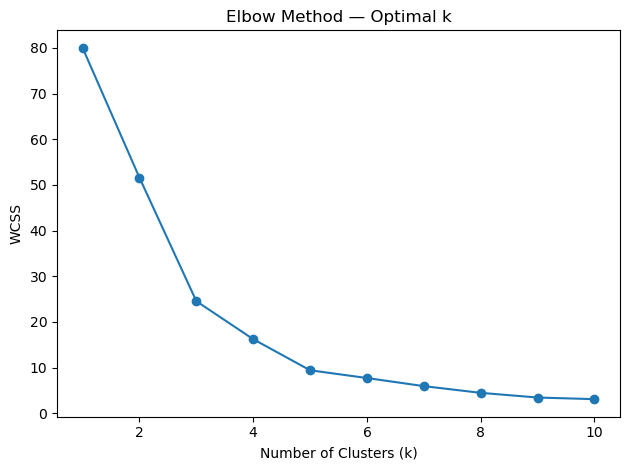

In [96]:
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method — Optimal k")
plt.tight_layout()
plt.show()

In [97]:
kmeans = KMeans(n_clusters=3, random_state=42)
station_recovery_2023["cluster"] = kmeans.fit_predict(X_scaled)
station_recovery_2023[["Two-Letter Station Code", "pop_density", "mhi", "cluster", "recovery_index"]].head(10)

,Two-Letter Station Code,pop_density,mhi,cluster,recovery_index
0,AN,4070.913,81512,0,0.627
1,AS,3770.370,118007,0,0.318
2,BF,9117.570,89149,0,0.394
3,BK,3770.370,118007,0,0.349
4,BP,24027.886,130906,1,0.315
5,CC,4827.782,142622,0,0.330
6,CL,11336.810,123552,0,0.283
7,CM,4391.093,123366,0,0.286
8,CN,3724.372,79790,0,0.371
9,CV,2873.222,125780,0,0.349


In [98]:
station_recovery_2023.groupby("cluster")["Two-Letter Station Code"].apply(list)

cluster
0    [AN, AS, BF, BK, CC, CL, CM, CN, CV, ED, EM, E...
1                                         [BP, MA, MT]
2                                 [DC, LF, MB, PH, WD]
Name: Two-Letter Station Code, dtype: object

In [99]:
station_recovery_2023.groupby("cluster")["recovery_index"].mean(0)

cluster
0   0.360
1   0.303
2   0.315
Name: recovery_index, dtype: float64

**Disclaimer**

"Based on demographic similarity to existing stations in Cluster 0, we project this station would perform similarly to those stations' recovery trajectory — reaching roughly 36% of its expected ridership potential in the post-COVID environment. Although this does say `recovery_index`, in this case, it would actually mean `relative performance projection` or `projected performance`.

In [100]:
X_proposed = proposed_df[["pop_density", "mhi"]]
X_proposed_scaled = scaler.transform(X_proposed)

proposed_df["cluster"] = kmeans.predict(X_proposed_scaled)
proposed_df[["station", "corridor", "pop_density", "mhi", "cluster"]]

,station,corridor,pop_density,mhi,cluster
0,28th St/Little Portugal,VTA Silicon Valley,13696.970,85818.000,1
1,Downtown San Jose,VTA Silicon Valley,7020.115,151685.000,0
2,Diridon,VTA Silicon Valley,4277.167,131491.000,0
3,Santa Clara,VTA Silicon Valley,7301.008,130051.000,0
4,Livermore (Isabel),East Bay,182.406,153602.000,2
5,Irvington,East Bay,2098.066,243552.000,2
6,Pittsburg Center,Contra Costa,2206.367,101099.000,0
7,Laurel Road,Contra Costa,3189.763,94256.000,0
8,Lone Tree Way,Contra Costa,4070.913,109673.000,0
9,Mokelumne Trail,Contra Costa,864.349,139567.000,0


In [101]:
cluster_recovery = station_recovery_2023.groupby("cluster")["recovery_index"].mean()
proposed_df["projected_performance"] = proposed_df["cluster"].map(cluster_recovery)
proposed_df[["station", "corridor", "cluster", "projected_performance"]]

,station,corridor,cluster,projected_performance
0,28th St/Little Portugal,VTA Silicon Valley,1,0.303
1,Downtown San Jose,VTA Silicon Valley,0,0.360
2,Diridon,VTA Silicon Valley,0,0.360
3,Santa Clara,VTA Silicon Valley,0,0.360
4,Livermore (Isabel),East Bay,2,0.315
5,Irvington,East Bay,2,0.315
6,Pittsburg Center,Contra Costa,0,0.360
7,Laurel Road,Contra Costa,0,0.360
8,Lone Tree Way,Contra Costa,0,0.360
9,Mokelumne Trail,Contra Costa,0,0.360


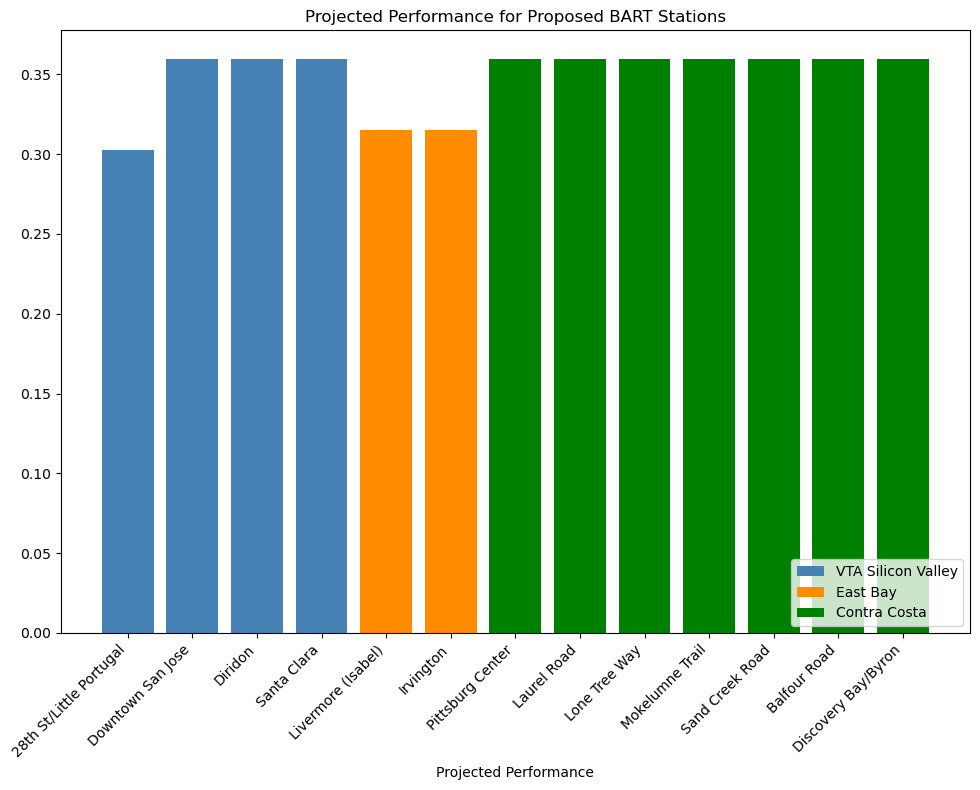

In [102]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = {"VTA Silicon Valley": "steelblue", "East Bay": "darkorange", "Contra Costa": "green"}

for _, row in proposed_df.iterrows():
    ax.bar(row["station"], row["projected_performance"], color=colors[row["corridor"]])

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
ax.legend(handles=legend_elements, loc="lower right")

ax.set_xlabel("Projected Performance")
ax.set_title("Projected Performance for Proposed BART Stations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Phase 5 Findings**

Projected performance varies across the three proposed corridors. Contra Costa stations are projected to reach 36% of baseline ridership, clustering with the suburban East Bay majority. East Bay additions (Livermore and Irvington) project at 31.5%, reflecting their high-income, low-density demographic profile. VTA Silicon Valley stations show mixed results — Downtown San Jose, Diridon, and Santa Clara project at 36%, while 28th St/Little Portugal projects lower at 30.3% due to its denser, lower-income neighborhood demographic clustering it with urban SF stations. Overall, no proposed corridor is projected to significantly outperform the existing system average, consistent with the broader finding that post-COVID recovery is driven by factors beyond demographics alone.

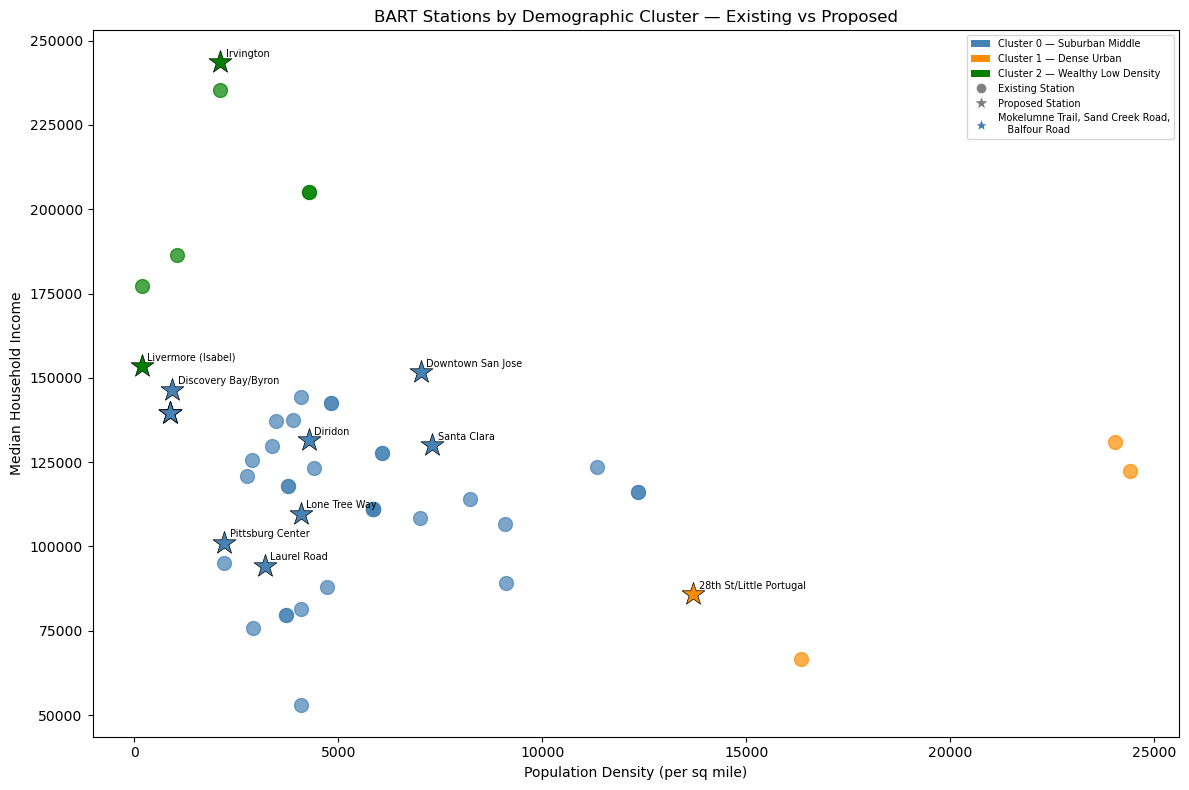

In [103]:
cluster_colors = {0: "steelblue", 1: "darkorange", 2: "green"}

fig, ax = plt.subplots(figsize=(12, 8))

# Existing stations — circles, no labels
for _, row in station_recovery_2023.iterrows():
    ax.scatter(row["pop_density"], row["mhi"], 
               color=cluster_colors[row["cluster"]], 
               marker="o", s=100, alpha=0.7)

# Stations to group in legend instead of labeling
grouped = ["Mokelumne Trail", "Sand Creek Road", "Balfour Road",]

# Proposed stations — stars, labels only for non-grouped
for _, row in proposed_df.iterrows():
    ax.scatter(row["pop_density"], row["mhi"], 
               color=cluster_colors[row["cluster"]], 
               marker="*", s=300, edgecolors="black", linewidths=0.5)
    if row["station"] not in grouped:
        ax.annotate(row["station"], 
                    (row["pop_density"], row["mhi"]),
                    fontsize=7, xytext=(4, 4), textcoords="offset points")

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Patch(facecolor="steelblue", label="Cluster 0 — Suburban Middle"),
    Patch(facecolor="darkorange", label="Cluster 1 — Dense Urban"),
    Patch(facecolor="green", label="Cluster 2 — Wealthy Low Density"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markersize=8, label="Existing Station"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="gray", markersize=12, label="Proposed Station"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="steelblue", markersize=10, 
           label="Mokelumne Trail, Sand Creek Road,\n   Balfour Road"),
]

ax.legend(handles=legend_elements, loc="upper right", fontsize=7)
ax.set_xlabel("Population Density (per sq mile)")
ax.set_ylabel("Median Household Income")
ax.set_title("BART Stations by Demographic Cluster — Existing vs Proposed")
plt.tight_layout()
plt.show()

## Phase 5 Findings

Using k-means clustering (k=3, determined by elbow method), existing BART 
stations were grouped into three demographic clusters:

- **Cluster 0 — Suburban Middle:** The largest group, covering most East Bay 
  and suburban stations. Average recovery index: 0.360.
- **Cluster 1 — Dense Urban:** BP, MA, MT — high density, lower income SF 
  stations. Average recovery index: 0.303.
- **Cluster 2 — Wealthy Low Density:** LF, WD, MB, PH — affluent, sparse 
  suburbs. Average recovery index: 0.315.

Proposed stations were scaled and assigned to their nearest cluster. Most 
Contra Costa and VTA stations cluster with Suburban Middle (0.360 projected 
recovery). Livermore and Irvington cluster with Wealthy Low Density (0.315). 
28th St/Little Portugal is the outlier, clustering with Dense Urban (0.303) 
due to its high density and lower household income relative to other VTA stations.

Disclaimer: These projections are based on demographic similarity to existing stations like Antioch to Laurel Road, 
not actual ridership data. They should be interpreted as relative performance 
benchmarks, not precise forecasts.

The hypothesis that Antioch (AN) would "mellow out" as more stations open 
along the SR-4 corridor remains plausible but untestable with current data. As Contra Costa stations like Lone Tree Way, Mokelumne Trail, and Balfour Road 
open, trips that currently terminate at Antioch may distribute across new stations. Just as Castro Valley was once the eastern edge of the East Bay corridor before further extensions, Antioch may follow a similar trajectory, transitioning from a terminus anchor to a mid-line station as the SR-4 corridor extends deeper into the San Joaquin Delta."